# 2.1 — A $k$-armed Bandit Problem

**Sutton & Barto, *Reinforcement Learning: An Introduction*, 2nd ed.**

---

## The setup

You face the same choice repeatedly. Each time you pick one of $k$ actions, and each
pick returns a numerical reward drawn from a **stationary probability distribution
that depends only on the action you chose**. You get 1000 such choices. Maximise the
total.

That is the whole problem. Nothing carries over between steps — no state, no
consequences for the future beyond what you *learn*. This is the simplest possible
setting in which the central tension of RL still appears.

## The value of an action

$$q_*(a) \;\doteq\; \mathbb{E}\!\left[R_t \mid A_t = a\right]$$

$q_*$ is a fixed but **unknown** function. If you knew it, the problem would be
trivial: always pick $\arg\max_a q_*(a)$. The entire difficulty is that you must
*estimate* it from noisy samples while simultaneously acting on those estimates.

We write $Q_t(a)$ for our estimate of $q_*(a)$ at step $t$. The goal is
$Q_t(a) \to q_*(a)$, or at least $\arg\max_a Q_t(a) = \arg\max_a q_*(a)$ — note
these are **not** the same requirement, and the second is the one that pays.

## Greedy, exploiting, exploring

At any step there is at least one action whose estimated value is greatest. Selecting
it is **exploiting** — the right move if you only care about *this* step. Selecting
anything else is **exploring** — it can only lower expected reward now, but it
improves $Q$, which pays out over all remaining steps.

$$\underbrace{\text{exploit}}_{\text{maximise reward now}} \quad\text{vs.}\quad \underbrace{\text{explore}}_{\text{improve future decisions}}$$

You cannot do both on the same step. Balancing them is the subject of this entire
chapter.

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
from bandit_utils import (Testbed, run_bandit, plot_pair, argmax_random_tiebreak,
                          hide, banner, RUNS, STEPS)

plt.rcParams["figure.dpi"] = 110
banner()

mode=FULL  runs=2000  steps=1000
switch with:  import os; os.environ['RL_MODE']='FULL'  (before importing)


## What one bandit problem actually looks like

Let us draw a single instance of the 10-armed testbed we will use throughout:
$q_*(a) \sim \mathcal{N}(0, 1)$ for each of the 10 arms, and pulling arm $a$ returns
$R \sim \mathcal{N}(q_*(a), 1)$.

Notice the two variances at play:
- **spread of the $q_*(a)$'s** — how much it *matters* which arm you pick;
- **spread of rewards around each $q_*(a)$** — how hard it is to *tell* which arm is which.

Their ratio is the difficulty knob of the whole problem.

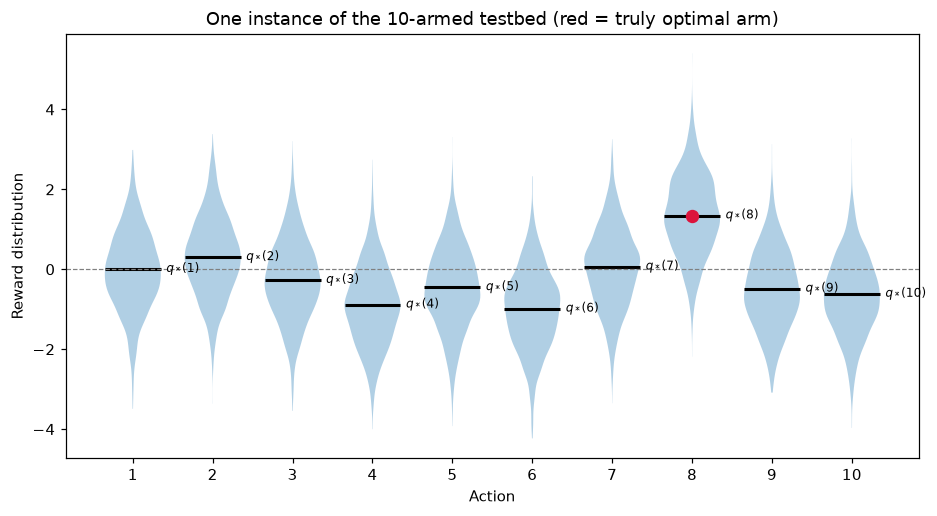

true values: [ 1.00e-03  2.99e-01 -2.74e-01 -8.91e-01 -4.55e-01 -9.92e-01  6.00e-02
  1.34e+00 -4.92e-01 -6.20e-01]
optimal arm: 8  gap to 2nd best: 1.041


In [2]:
rng = np.random.default_rng(7)
k = 10
q_star = rng.normal(0, 1, size=k)

samples = rng.normal(q_star, 1.0, size=(2000, k))

fig, ax = plt.subplots(figsize=(10, 5))
parts = ax.violinplot(samples, positions=np.arange(1, k + 1), widths=0.7,
                      showmeans=False, showextrema=False)
for pc in parts["bodies"]:
    pc.set_alpha(0.35)
ax.hlines(q_star, np.arange(1, k + 1) - 0.35, np.arange(1, k + 1) + 0.35,
          color="k", lw=2)
for a in range(k):
    ax.text(a + 1.42, q_star[a], f"$q_*({a+1})$", va="center", fontsize=8)
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.scatter([q_star.argmax() + 1], [q_star.max()], color="crimson", zorder=5, s=60)
ax.set_xlabel("Action")
ax.set_ylabel("Reward distribution")
ax.set_title("One instance of the 10-armed testbed (red = truly optimal arm)")
ax.set_xticks(np.arange(1, k + 1))
plt.show()

print("true values:", np.round(q_star, 3))
print("optimal arm:", q_star.argmax() + 1, " gap to 2nd best:",
      round(np.sort(q_star)[-1] - np.sort(q_star)[-2], 3))

---

### Predict first

Look at the violin plot above. Suppose you pull **each arm exactly once** and
then commit forever to whichever arm gave the highest single reward.

1. Roughly what fraction of the time do you think you would land on the truly best arm?
2. Does that fraction depend more on the *gap* between the top arms, or on the reward noise?

*Write your guess down (mentally or in the cell below) before running the next cell. The point is not to be right — it is to make the surprise informative when you are wrong.*

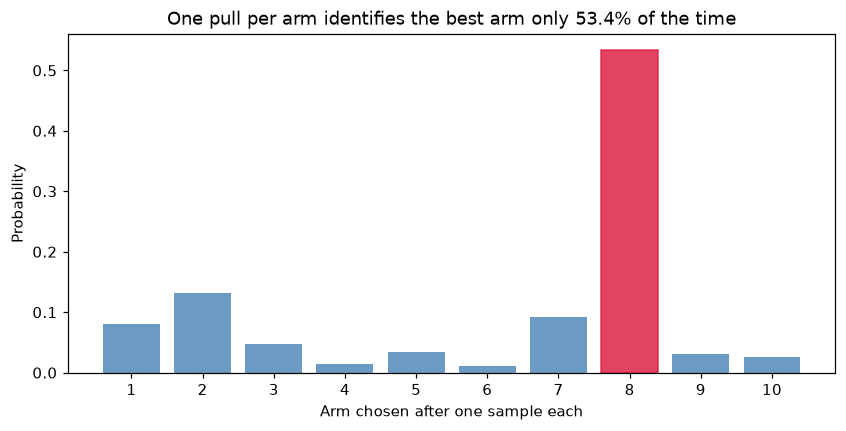

In [ ]:
trials = 20000
rng2 = np.random.default_rng(1)

one_shot = rng2.normal(q_star, 1.0, size=(trials, k))
picked = one_shot.argmax(axis=1)
hit_rate = (picked == q_star.argmax()).mean()

fig, ax = plt.subplots(figsize=(9, 4))
counts = np.bincount(picked, minlength=k) / trials
bars = ax.bar(np.arange(1, k + 1), counts, color="steelblue", alpha=0.8)
bars[q_star.argmax()].set_color("crimson")
ax.set_xlabel("Arm chosen after one sample each")
ax.set_ylabel("Probability")
ax.set_title(f"One pull per arm identifies the best arm only {hit_rate:.1%} of the time")
ax.set_xticks(np.arange(1, k + 1))
plt.show()

hide(f'''
About <b>{hit_rate:.0%}</b>. That is much better than the 10% you would get by
guessing &mdash; a single sample <i>does</i> carry real information, and it is more than
enough to rule out the clearly terrible arms, which is why the distribution above
concentrates on the top three or four.

<br><br>

But it still means committing to a suboptimal arm roughly half the time, forever.
The reason is that the reward noise (&sigma;=1) is comparable to the spacing between the
<i>top</i> few q* values &mdash; exactly the arms you need to discriminate between.
Easy comparisons are easy; the one comparison that matters is hard.

<br><br>

So exploration cannot be a one-off "calibration phase" followed by pure
exploitation: one round of data is nowhere near enough.
</div>
''')

## How much data *does* it take?

Since one sample per arm is not enough, how many do we need before the sample means
rank the arms correctly? The standard error of a mean of $n$ samples is
$\sigma/\sqrt{n}$, so to distinguish two arms separated by a gap $\Delta$ we need
roughly

$$n \;\gtrsim\; \frac{\sigma^2}{\Delta^2}$$

samples *of each*. Small gaps are expensive. Note the good news hiding in this: when
the gap is small, getting it wrong is also cheap. That trade-off is exactly what the
regret analyses of bandit theory formalise.

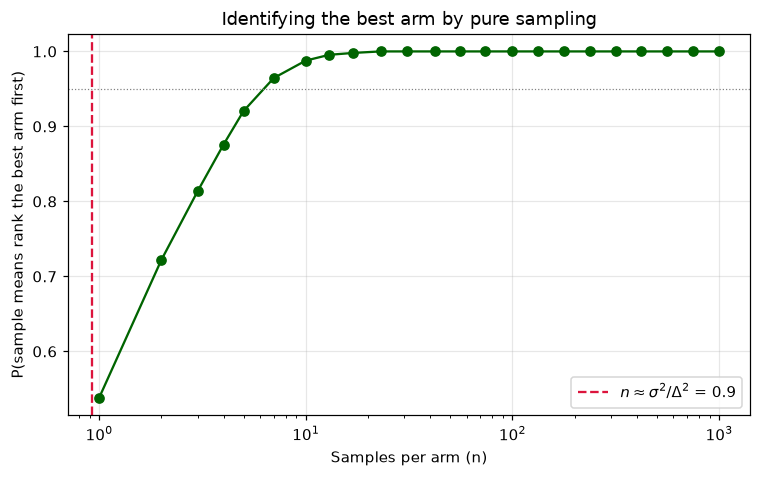

In [4]:
ns = np.unique(np.logspace(0, 3, 25).astype(int))
trials = 4000
rng3 = np.random.default_rng(3)
acc = []
for n in ns:
    means = rng3.normal(q_star, 1.0 / np.sqrt(n), size=(trials, k))
    acc.append((means.argmax(axis=1) == q_star.argmax()).mean())

gap = np.sort(q_star)[-1] - np.sort(q_star)[-2]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(ns, acc, "o-", color="darkgreen")
ax.axvline(1.0 / gap**2, color="crimson", ls="--",
           label=r"$n \approx \sigma^2/\Delta^2$" + f" = {1/gap**2:.1f}")
ax.axhline(0.95, color="gray", ls=":", lw=0.8)
ax.set_xlabel("Samples per arm (n)")
ax.set_ylabel("P(sample means rank the best arm first)")
ax.set_title("Identifying the best arm by pure sampling")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## Regret: the other way to score yourself

Average reward is the natural objective, but **regret** makes the cost of learning
explicit. The expected regret after $T$ steps is

$$L_T \;=\; \sum_{t=1}^{T}\Big( \max_a q_*(a) \;-\; q_*(A_t) \Big)
\;=\; \sum_{a} \Delta_a \, \mathbb{E}[N_T(a)], \qquad \Delta_a = q_*(a^*) - q_*(a)$$

where $N_T(a)$ counts how often $a$ was chosen. Read the right-hand form carefully:
**regret is a weighted count of mistakes**, weighted by how bad each mistake is. An
algorithm can pull a nearly-tied arm constantly and still have low regret.

The shape of the regret curve tells you what kind of algorithm you have:

| Regret growth | Meaning |
|---|---|
| $\Theta(T)$ (linear) | never stops making a constant rate of costly mistakes — e.g. fixed-$\varepsilon$ greedy |
| $\Theta(\log T)$ (sublinear) | mistakes get rarer over time — UCB, decaying $\varepsilon$ |
| $\Theta(0)$ | impossible without prior knowledge |

We will come back to this at the end of the chapter.

## Exercise 2.1 (from the book)

> In $\varepsilon$-greedy action selection, for the case of two actions and
> $\varepsilon = 0.5$, what is the probability that the greedy action is selected?

$$P(\text{greedy}) = \underbrace{(1-\varepsilon)}_{\text{deliberate exploit}} + \underbrace{\varepsilon \cdot \tfrac{1}{k}}_{\text{explore, land on it anyway}} = 0.5 + 0.5\cdot\tfrac12 = \boxed{0.75}$$

The second term is the one people forget: $\varepsilon$-greedy explores *uniformly over
all actions*, including the greedy one. Verify it below — and change `k` to convince
yourself of the general formula $1 - \varepsilon + \varepsilon/k$.

In [5]:
def greedy_prob_empirical(eps, k, n=200000, seed=0):
    rng = np.random.default_rng(seed)
    explore = rng.random(n) < eps
    choice = np.where(explore, rng.integers(0, k, size=n), 0)
    return (choice == 0).mean()

for eps, k_ in [(0.5, 2), (0.1, 10), (0.01, 10), (0.3, 4)]:
    emp = greedy_prob_empirical(eps, k_)
    theory = 1 - eps + eps / k_
    print(f"eps={eps:<5} k={k_:<3} empirical={emp:.4f}  theory={theory:.4f}")

eps=0.5   k=2   empirical=0.7492  theory=0.7500
eps=0.1   k=10  empirical=0.9096  theory=0.9100
eps=0.01  k=10  empirical=0.9909  theory=0.9910
eps=0.3   k=4   empirical=0.7751  theory=0.7750


## Takeaways for 2.1

1. $q_*(a)$ is a fixed unknown; $Q_t(a)$ is your estimate. All the action is in the gap
   between them.
2. A single sample per arm is nearly worthless when reward noise is comparable to the
   gaps between arms — so exploration cannot be a finite warm-up phase.
3. Difficulty scales as $\sigma^2/\Delta^2$, but so does the cheapness of being wrong.
4. Regret = mistakes weighted by their cost. Its *growth rate* classifies algorithms.

**Next:** how to actually form $Q_t(a)$, and the simplest rule for balancing the
trade-off — Section 2.2.